<a href="https://colab.research.google.com/github/AtifShams/Data_Analysis_Projects/blob/main/Sales_Data_Analysis_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import kagglehub
import pandas as pd
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import seaborn as sns
#!pip install mplcursors
import mplcursors
import plotly.express as px
import os
import plotly.io as pio
#!pip install kaleido
#!pip install --upgrade plotly # Added to upgrade Plotly for Kaleido compatibility
import kaleido
pio.renderers.default = "colab"

In [6]:
path = kagglehub.dataset_download('vivek468/superstore-dataset-final')
csv_file = f'{path}/Sample - Superstore.csv'

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.


In [7]:
df = pd.read_csv(csv_file,encoding='windows-1252')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df['Postal Code'] = df['Postal Code'].fillna(0).astype(int)

In [9]:
print(df['Postal Code'])

0       42420
1       42420
2       90036
3       33311
4       33311
        ...  
9989    33180
9990    92627
9991    92627
9992    92627
9993    92683
Name: Postal Code, Length: 9994, dtype: int64


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [11]:
df = df.drop_duplicates()
df.nunique()

,0
Row ID,9994
Order ID,5009
Order Date,1237
Ship Date,1334
Ship Mode,4
Customer ID,793
Customer Name,793
Segment,3
Country,1
City,531


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')

In [14]:
df1 = df['Order Date'].dt.strftime('%b')
df2 = df['Order Date'].dt.strftime('%Y')
df['Order Month'] = df1 + " " + df2
print(df['Order Month'].head())

0    Nov 2016
1    Nov 2016
2    Jun 2016
3    Oct 2015
4    Oct 2015
Name: Order Month, dtype: object


In [15]:
df['Profit Ratio'] = df['Profit']/df['Sales']
print(df['Profit Ratio'])

0       0.1600
1       0.3000
2       0.4700
3      -0.4000
4       0.1125
         ...  
9989    0.1625
9990    0.1700
9991    0.0750
9992    0.4500
9993    0.3000
Name: Profit Ratio, Length: 9994, dtype: float64


In [16]:
Total_Sales = sum(df['Sales'])
print('Total Sales: ', Total_Sales)

Total Sales:  2297200.8603


In [17]:
df['Order Month'] = df['Order Date'].dt.to_period('M')
Monthly_Sale = df.groupby('Order Month')['Sales'].sum().reset_index()

print(Monthly_Sale.head())

  Order Month      Sales
0     2014-01  14236.895
1     2014-02   4519.892
2     2014-03  55691.009
3     2014-04  28295.345
4     2014-05  23648.287


In [18]:
# Max Sales in a Month
Max_Sales_Month = Monthly_Sale.sort_values(by = 'Sales', ascending=False).head(1).reset_index()
print(Max_Sales_Month)

   index Order Month       Sales
0     46     2017-11  118447.825


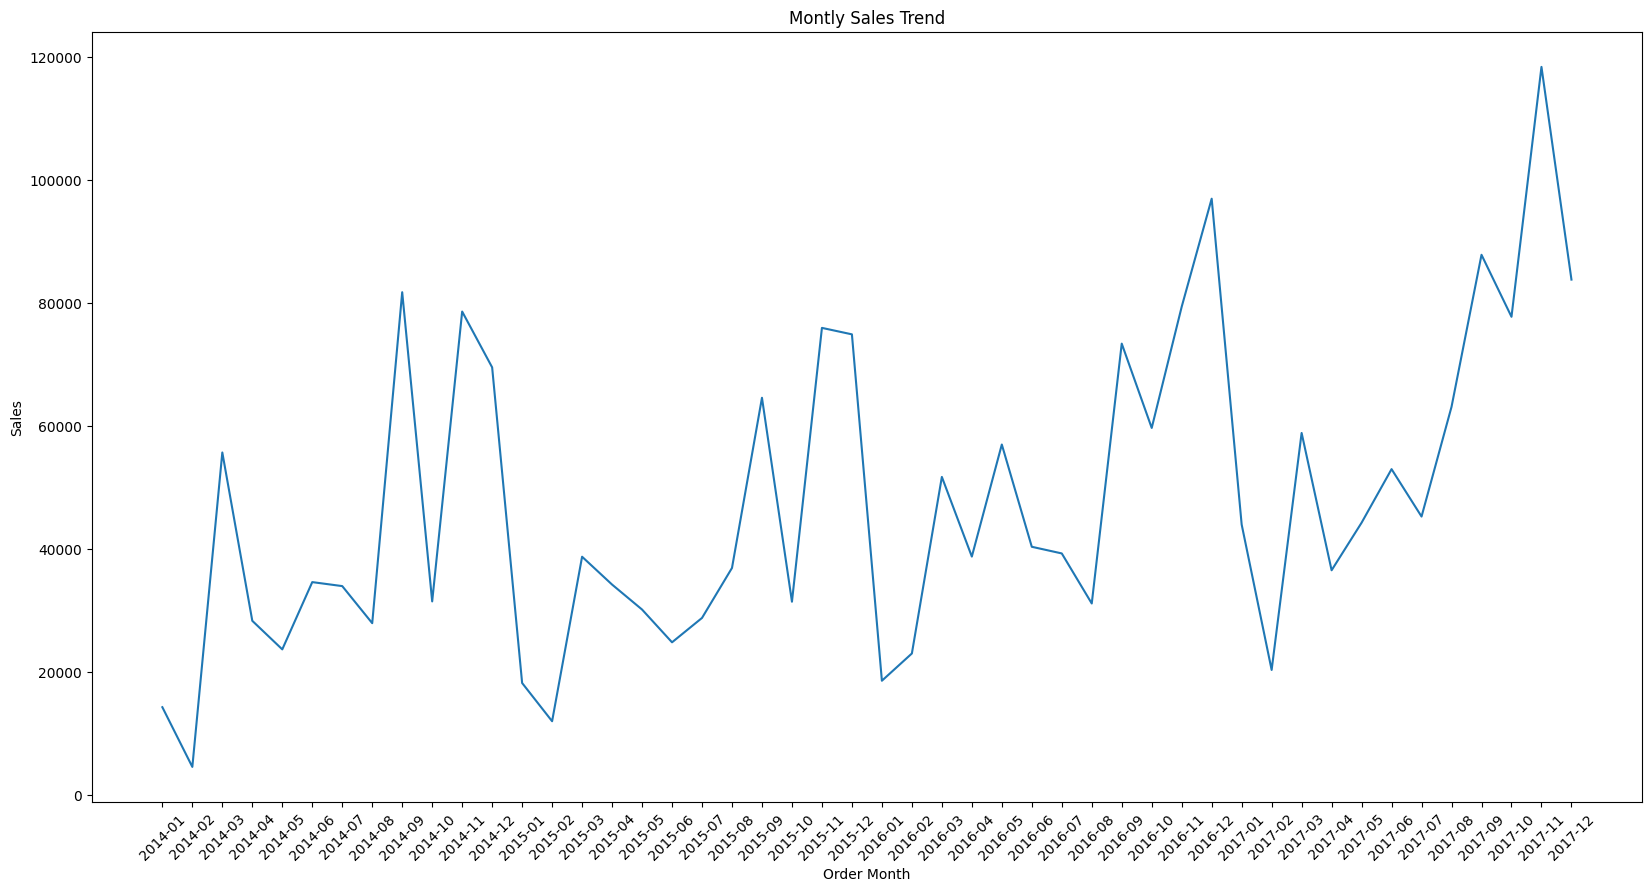

In [19]:
plt.figure(figsize =(20,10))
sns.lineplot(data=Monthly_Sale, x= Monthly_Sale['Order Month'].astype(str), y='Sales')
plt.xticks(rotation=45)
plt.title("Montly Sales Trend")
plt.show()

In [20]:
#Interactive Monthly Sales Trend Chart
Monthly_Sale['Month'] = Monthly_Sale['Order Month'].astype(str)
fig = px.line(Monthly_Sale, x='Month', y='Sales', title='Interactive Monthly Sales Trend')
try:
    fig.show('png')
except Exception as e:
    print(f"Static export failed, showing interactive version: {e}")
    fig.show()

Static export failed, showing interactive version: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome




In [21]:
#Top 10 Selling Products
Top_Products = df.groupby('Product Name')['Sales'].sum().reset_index()
Top_10 = Top_Products.sort_values(by = 'Sales', ascending=False).head(10).reset_index()
print(Top_10)

   index                                       Product Name      Sales
0    404              Canon imageCLASS 2200 Advanced Copier  61599.824
1    650  Fellowes PB500 Electric Punch Plastic Comb Bin...  27453.384
2    444  Cisco TelePresence System EX90 Videoconferenci...  22638.480
3    786       HON 5400 Series Task Chairs for Big and Tall  21870.576
4    686         GBC DocuBind TL300 Electric Binding System  19823.479
5    688   GBC Ibimaster 500 Manual ProClick Binding System  19024.500
6    805               Hewlett Packard LaserJet 3310 Copier  18839.686
7    787  HP Designjet T520 Inkjet Large Format Printer ...  18374.895
8    683          GBC DocuBind P400 Electric Binding System  17965.068
9    813        High Speed Automatic Electric Letter Opener  17030.312


In [22]:
#Most Profitable Category
Profit_Sum = df.groupby('Category')['Profit'].sum().reset_index()
Most_Profitable_Category = Profit_Sum.sort_values(by = 'Profit', ascending=False).head(1).reset_index()
print(Most_Profitable_Category)

   index    Category       Profit
0      2  Technology  145454.9481


In [23]:
#Bar chart : Sales by category
Sales_by_Category = df.groupby('Category')['Sales'].sum().reset_index()
fig = px.bar(Sales_by_Category, x='Category', y='Sales', title='Sales by Category')
try:
    fig.show('png')
except Exception as e:
    print(f"Static export failed, showing interactive version: {e}")
    fig.show()

Static export failed, showing interactive version: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome




In [24]:
#Loss Making Products
Product_profit = df.groupby('Product Name')['Profit'].sum().reset_index()
Loss_Making_Product = Product_profit.where(Product_profit['Profit'] < 0).dropna().reset_index()
print(Loss_Making_Product)

     index                                       Product Name    Profit
0       17  3.6 Cubic Foot Counter Height Office Refrigerator -872.0752
1       18                           36X48 HARDFLOOR CHAIRMAT  -40.4914
2       20     3D Systems Cube Printer, 2nd Generation, White -467.9964
3       26  3M Replacement Filter for Office Air Cleaner f...  -20.4768
4       35  ARKON Windshield Dashboard Air Vent Car Mount ...  -15.5940
..     ...                                                ...       ...
296   1837  XtraLife ClearVue Slant-D Ring Binders by Card...  -13.3280
297   1838  Zebra GK420t Direct Thermal/Thermal Transfer P... -938.2800
298   1843                  i.Sound Portable Power - 8000 mAh  -58.8189
299   1846                         iOttie HLCRIO102 Car Mount  -11.9940
300   1847                                iOttie XL Car Mount  -50.3748

[301 rows x 3 columns]


In [25]:
Sales_by_City = df.groupby('City')['Sales'].sum().reset_index()
Top_10_Cities = Sales_by_City.sort_values(by = 'Sales', ascending=False).head(10).reset_index()
print(Top_10_Cities)

   index           City        Sales
0    329  New York City  256368.1610
1    266    Los Angeles  175851.3410
2    452        Seattle  119540.7420
3    438  San Francisco  112669.0920
4    374   Philadelphia  109077.0130
5    207        Houston   64504.7604
6     80        Chicago   48539.5410
7    437      San Diego   47521.0290
8    216   Jacksonville   44713.1830
9    464    Springfield   43054.3420


In [26]:
Profit_by_region = df.groupby('Region')['Profit'].sum().reset_index()
Profit_by_region = Profit_by_region.sort_values(by = 'Profit', ascending=False).reset_index()
print(Profit_by_region)

   index   Region       Profit
0      3     West  108418.4489
1      1     East   91522.7800
2      2    South   46749.4303
3      0  Central   39706.3625


In [27]:
fig = px.pie(df, values='Profit', names='Region', title='Profit by Region')
try:
    fig.show('png')
except Exception as e:
    print(f"Static export failed, showing interactive version: {e}")
    fig.show()

Static export failed, showing interactive version: 

Kaleido requires Google Chrome to be installed.

Either download and install Chrome yourself following Google's instructions for your operating system,
or install it from your terminal by running:

    $ plotly_get_chrome




In [28]:
### Key Insights Summary

# 1. Total Sales (Jan 2014 - Dec 2017): $2,297,200.86
# 2. Peak Monthly Sales: November 2017 reached a value of $118,447.83.
# 3. Most Profitable Category: Technology, with a total profit of $145,454.95.
# 4. Product Profitability: 301 out of 1,850 products (approx. 16%) are currently loss-making.
# 5. Top Performing City: New York City generated the highest sales, totaling $256,368.16.
# 6. Most Profitable Region: The West region led with a total profit of $108,418.45.